# Required assignment 13.1: Optimising a logistic function in Python

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Introduction

In this notebook, you will explore how to use logistic regression to predict the onset of diabetes using the [Pima Indians diabetes data set](https://www.kaggle.com/uciml/pima-inidans-diabetes-database). This notebook will walk you through the process of data preparation, model building, parameter selection and model evaluation with a focus on practical interpretation.

Specifically, you will:

- Work with the Pima Indians diabetes data set. 

- Build a logistic regression model.

- Choose the best parameters.

- Select the probability threshold based on the false positive rate (FPR) and the false negative rate (FNR).

## Download and prepare the data

### Question 1

- Review the `diabetes.csv` data set and store it in the variable `data`.

- Display the columns of the data set and assign them to `columns`.  

In [2]:
###GRADED CELL
data = pd.read_csv('data/diabetes.csv')
columns = data.columns
print("The columns in the dataset are given by ", columns)

The columns in the dataset are given by  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


## Preprocess the data

Check for null values in the data.

In [3]:
print (data.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Split the data into inputs and outputs.

### Question 2

- Identify the inputs and outputs of the data. Assign them to variables `inputs` and `outputs`, respectively. 

- Assign the inputs to `X`.

- Assign the outputs to `Y`.

Hint: Ensure that the output is a 1D array of shape (`n_samples`).

In [5]:
###GRADED CELL
inputs = data.drop(columns=['Outcome'])
outputs = data['Outcome']
X = inputs
Y = outputs

print("The inputs are given by :", X.head())
print("The outputs are given by :", Y[:5])

The inputs are given by :    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
The outputs are given by : 0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


Preprocess the data using the `StandardScaler()` function.

In [6]:
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

- Divide the data set into a 70/30 training and testing split.

### Question 3

- Use `train-test-split()` to split the data into 70 per cent training and 30 per cent testing sets.

- Use `random_state =42`.

In [7]:
###GRADED CELL

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,         # 30% for testing, 70% for training
    random_state=42        # For reproducibility
)

print("The shape of X_train is ", X_train.shape)
print("The shape of X_test is ", X_test.shape)

The shape of X_train is  (537, 8)
The shape of X_test is  (231, 8)


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Build a logistic regression model

Recall that logistic regression models the relationship between one or more independent variables and a binary dependent variable by applying a sigmoid (logistic) function to produce an output between 0 and 1, representing the estimated probability of the event. It is a simple, interpretable model that is commonly used for binary classification problems.

### Question 4

- Create a `LogisticRegression` model with `penalty=None`  and assign it to `model`.

- Use the `.fit()` to train the model.

- Make predictions and assign them to `Y_train_pred` and `Y_test_pred`, respectively. 


In [9]:
###GRADED CELL
model = LogisticRegression(penalty=None, max_iter=1000)
model.fit(X_train, Y_train)
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)
print("The shape of Y_train_pred is ", Y_train_pred.shape)
print("The shape of Y_test_pred is ", Y_test_pred.shape)

The shape of Y_train_pred is  (537,)
The shape of Y_test_pred is  (231,)


/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Question 5

- Compute the confusion matrices for the training and testing data sets and assign them to `confusion_matrix_train` and `confusion_matrix_test`, respectively. 

- Compute the `train_accuracy` and `test_accuracy` using the `accuracy_score()` of `sklearn_metrics`.

In [10]:
###GRADED CELL
confusion_matrix_train = confusion_matrix(Y_train, Y_train_pred)
confusion_matrix_test = confusion_matrix(Y_test, Y_test_pred)
train_accuracy = accuracy_score(Y_train, Y_train_pred)
test_accuracy = accuracy_score(Y_test, Y_test_pred)

# YOUR CODE HERE
print('Training Confusion Matrix', confusion_matrix_train)

print()
print('Testing Confusion Matrix', confusion_matrix_test)

print()
print('Training accuracy', train_accuracy)

print()
print('Testing accuracy', test_accuracy)


Training Confusion Matrix [[310  39]
 [ 78 110]]

Testing Confusion Matrix [[120  31]
 [ 30  50]]

Training accuracy 0.7821229050279329

Testing accuracy 0.7359307359307359


## Choose the best parameters

Regularisation involves adding a penalty to the loss function to reduce model complexity and help prevent overfitting. Ideally, this leads to better generalisation.

- Analyse the effect of L2 regularisation by examining how testing accuracy changes with different values of $C$. 

- Create a plot that shows how $C$ varies, starting at $10^{-6}$ and ending at $10^{-2}$.

### Question 6

- Create a `LogisticRegression` model with `penalty='l2` and `max_iter=1000`.

- Use `GridSearchCV` with cross-validation `cv=5` and `scoring=accuracy`. 

- Compute the `mean_test_score` of  `grid_search.cv_results_` and assign it to `mean_accuracies`.

In [12]:
###GRADED CELL

C_space = np.linspace(10e-6, 10e-2, 200)
param_grid = {'C': C_space}
logreg = LogisticRegression(l1_ratio=0, max_iter=1000)
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)
mean_accuracies = grid_search.cv_results_['mean_test_score']

# YOUR CODE HERE
print('The mean_accuracies is given by ', mean_accuracies)


The mean_accuracies is given by  [0.64991346 0.64991346 0.64991346 0.64993077 0.65737279 0.67410869
 0.69084458 0.69643475 0.7039287  0.71881274 0.71883004 0.72997577
 0.7411388  0.73932156 0.73746971 0.74119072 0.74117342 0.74861544
 0.75417099 0.75417099 0.75417099 0.75417099 0.75230183 0.75230183
 0.75417099 0.75417099 0.75417099 0.75976116 0.76161301 0.76161301
 0.76161301 0.76161301 0.76348217 0.76535133 0.76535133 0.76348217
 0.76348217 0.76348217 0.76533403 0.76533403 0.76533403 0.76720318
 0.76720318 0.76533403 0.76533403 0.76718588 0.76718588 0.76905504
 0.7709242  0.7709242  0.7709242  0.7709242  0.7709242  0.7709242
 0.77279335 0.77279335 0.77279335 0.77279335 0.77279335 0.77279335
 0.77279335 0.77464521 0.77464521 0.77464521 0.77464521 0.77464521
 0.77651436 0.77651436 0.77651436 0.77651436 0.77651436 0.77464521
 0.77464521 0.77649706 0.77649706 0.77649706 0.77649706 0.77649706
 0.77649706 0.77649706 0.77649706 0.77649706 0.77649706 0.77649706
 0.77649706 0.77649706 0.77649

Text(0.5, 1.0, 'Analysis of Regularisation')

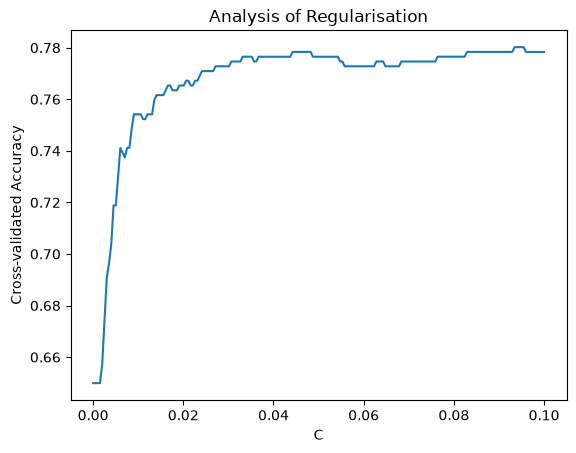

In [13]:
plt.plot(C_space, mean_accuracies)
plt.xlabel('C')
plt.ylabel('Cross-validated Accuracy')
plt.title('Analysis of Regularisation')



### Question 7

- Identify the `best_C` value and its corresponding cross-validated accuracy.

- Print the `best_C` and `best_accuracy` by computing the `best_index`.

- Print the `test_accuracy` on the `best_model`.

Hint: `best_model` can be obtained using `grid_search.best_estimator_`.

In [14]:
###GRADED CELL
best_C = grid_search.best_params_['C']
best_accuracy = grid_search.best_score_
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, Y_test)
# YOUR CODE HERE

print(f'Best cross-validated accuracy was achieved with C = {best_C}, giving an accuracy of {best_accuracy:.4f}.')



print(f'Accuracy of the best model on the test set: {test_accuracy:.4f}')


Best cross-validated accuracy was achieved with C = 0.09346798994974874, giving an accuracy of 0.7802.
Accuracy of the best model on the test set: 0.7403


## Select the probability threshold based on the FPR and FNR

Recall that you're not estimating $Y$ ddirectly; you're estimating the probability of $Y = 1 | X$.

So far, classification has been based on selecting the class with the higher probability. In other words, you've been using the following classifier:
$$
  \hat{Y}(x) =
    \begin{cases}
      0 & \text{if } \hat{p}(x) < 0.5 \\
      1 & \text{if } \hat{p}(x) \geq 0.5 \\
    \end{cases}       
$$

However, you also need to consider that the probability threshold of 0.5 may not be optimal.

### Question 8

- Implement a function `predict_with_threshold` that takes a trained logistic regression model, a feature matrix X and a probability threshold. It should return class predictions (0 or 1) based on whether the predicted probability for class 1 is greater than or equal to the threshold. 

- For thresholds ranging from 0 to 1, compute and store the FNR and FPR on the test set.

- Plot the FNR and FPR as functions of the threshold to observe how these metrics change with varying thresholds.

Hint: Use the `confusion_matrix` function from `sklearn.metrics` to compute the FNR and FPR.

In [16]:
###GRADED CELL

model = LogisticRegression(l1_ratio = 0, C = best_C)
model.fit(X_train, Y_train)
#Define predict_with_threshold(model,X,threshold):

def predict_with_threshold(model, X, threshold):
    probs_class1 = model.predict_proba(X)[:, 1]
    preds = (probs_class1 >= threshold).astype(int)
    return preds


#Calculate the probabilities and use the second column, which represents the probabilities
#Build an array of Boolean variables, checking whether the probabilities are larger than or equal to the threshold
#Compute predictions by transforming the Boolean variables and making them integers
#Return predictions




### Question 9

- Compute the number of true positives and assign it to `num_of_positives`. 

- Compute the number of true negatives and assign it to `num_of_negatives`.

In [17]:
thresholds = np.linspace(0, 1, 101)

false_negatives = []
false_positives = []

# counts for normalising rates
num_of_positives = np.sum(Y_test == 1)  # TP + FN
num_of_negatives = np.sum(Y_test == 0)  # TN + FP

print("The number of true positives is ", num_of_positives)
print("The number of true negatives is ", num_of_negatives)

for tp in thresholds:
    Y_pred = predict_with_threshold(model, X_test, tp)
    cm = confusion_matrix(Y_test, Y_pred)
    fnr = cm[1, 0] / num_of_positives
    fpr = cm[0, 1] / num_of_negatives
    false_negatives.append(fnr)
    false_positives.append(fpr)

The number of true positives is  80
The number of true negatives is  151


The FNR and FPR are plotted against the probability threshold.

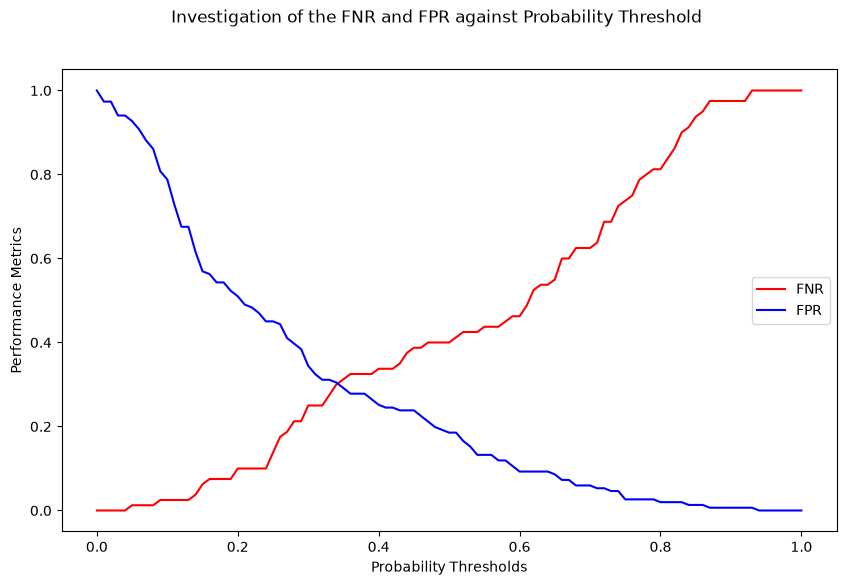

In [18]:
#Create a plot to see how the rates change with the threshold
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_figheight(6)
fig.set_figwidth(10)
fig.suptitle('Investigation of the FNR and FPR against Probability Threshold')

ax.plot(thresholds, false_negatives, 'r', label = 'FNR')
ax.plot(thresholds, false_positives, 'b', label = 'FPR')
ax.set_ylabel('Performance Metrics')
ax.set_xlabel('Probability Thresholds')
ax.legend()

When the threshold is lowered, the FPR increases, while the FNR decreases. Conversely, increasing the threshold decreases the FPR and increases the FNR. The optimal threshold depends on the context of the problem and the relative costs of false positives and false negatives. 

The point where the FPR and FNR curves intersect on the probability threshold plot is a reasonable candidate as the 'best threshold', assuming that false positives and false negatives are equally costly.